# ETH Data Analysis — Exam Cheat Sheet

**Contents**
- **A. Foundations** — arrays, I/O, sampling/resolution, mean/std/SEM, error propagation
- **B. Signal processing** — covariance, autocorrelation, Fourier, Parseval, filtering, PSD
- **C. Probability & fitting** — PMF/moments, normal dist., CLT, least squares, curve_fit, gradient descent
- **D. Machine learning** — regression, classification, data cleaning, KNN/trees, k-means
- **E. Bonus** — exponential waiting times, sensor accuracy model + Bayes, model comparison


In [70]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.optimize import curve_fit
from scipy.stats import expon
import pandas as pd

DATA = 'data'   # all example datasets used below live in ExamLibary/data/
#np.random.seed(0)
plt.rcParams['figure.dpi'] = 90


## Quick Formula Reference

| Quantity | Formula |
|---|---|
| Sampling rate | $f_s = 1/\Delta t$; Nyquist $f_{Ny}=f_s/2$; freq. resolution $\Delta f = 1/(N\Delta t)$ |
| Sample mean / std | $\mu=\frac1N\sum x_i$; $\sigma_{\text{pop}}$: `ddof=0`; $\sigma_{\text{sample}}$: `ddof=1` (÷(N-1)) |
| SEM | $\sigma_{\bar x} = \sigma/\sqrt N$ |
| Error propagation | $\sigma_f=\sqrt{\sum_i(\partial f/\partial x_i)^2\sigma_{x_i}^2}$ (uncorrelated) |
| Covariance | $\sigma_{xy}=\frac1{N-1}\sum(x_i-\bar x)(y_i-\bar y)$; $\rho=\sigma_{xy}/(\sigma_x\sigma_y)$ |
| Autocovariance | $R_{xx}(\Delta i)=\frac1{N-\Delta i}\sum (x_i-\bar x)(x_{i+\Delta i}-\bar x)$, $\tau=\Delta i\,\Delta t$ |
| DFT | $X_n=\sum_k x_k e^{-i2\pi kn/N}$ (`np.fft.fft`, unnormalized); amplitude $a_n = X_n/N$ |
| Parseval | $\mathrm{Var}(x)=\sum_n \mathrm{PSD}(f_n)\,\Delta f$ (one-sided density PSD) |
| Moments | raw $m_n=\frac1M\sum X_j^n$; central $\mu_n=\frac1M\sum(X_j-\bar X)^n$; skew $=\mu_3/\sigma^3$; kurt $=\mu_4/\sigma^4-3$ |
| Gaussian PDF | $f(x)=\frac1{\sqrt{2\pi\sigma^2}}e^{-(x-\mu)^2/2\sigma^2}$; FWHM $=2\sigma\sqrt{2\ln2}$ |
| CLT | sample-mean dist. $\to\mathcal N(\mu,\ \sigma/\sqrt n)$ |
| Weighted least squares | minimize $S=\sum_i (y_i-f(x_i))^2/\sigma_i^2$ ( = $\chi^2$); reduced $\chi^2_\nu = S/(N-\#\text{params})$ |
| Gradient descent | $\vec a \leftarrow \vec a-\alpha\nabla S$; param cov $= H^{-1}$ at optimum |
| $R^2$ | $1-SS_{res}/SS_{tot}$ |
| Logistic regression | $p=\sigma(w^\top x+b)=1/(1+e^{-(w^\top x + b)})$ |
| K-means | assign to nearest centroid $\to$ recompute centroid as mean $\to$ repeat |
| Exponential waiting time | $f(t)=\frac1\tau e^{-t/\tau}$; MLE $\hat\tau=\bar t$ |

**Data files used below** (all in `data/`, copied verbatim from the course exercises):
`osc_data.txt`, `voltage_timeseries.txt`, `geschwindigkeiten.txt`, `data_xyz.txt`, `signal_1.txt`,
`signal.txt`, `square.txt`, `noisy_pulse.txt`, `peaks.txt`, `autocorrelation_laser.txt`,
`voltages_pmf.txt`, `nasa_periods.txt`, `lin_data.txt`, `poly_data.txt`, `decay.txt`,
`earthquake_waiting_times.txt`, `seismic_test_dataset.txt`, `luftsensor_studie.txt`,
`advertising.csv`, `cancer.csv`, `spiral_train.csv`, `spiral_test.csv`, `titanic.csv`,
`ensemble_train.csv`, `ensemble_new.csv`.


---
# Part A — Foundations (Ex01–Ex04)
---

## A1. NumPy Arrays — Creation, Indexing, Slicing

Indices start at `0`. Slice `a[start:stop:step]` selects values between `start` and `stop`
(**stop excluded**). Negative indices count from the end (`-1` = last element).


In [71]:
# --- creation ---
a  = np.array([0.1, 0.2, 0.3])                     # 1D
b  = np.zeros(5); c = np.ones(5)                   # default dtype float64
d  = np.ones(5, dtype=int)
a2 = np.array([[0.1, 0.2, 0.3],
               [1.1, 1.2, 1.3]])                   # 2D: rows must have same length

# --- indexing / slicing ---
print(a[0], a[-1], a[-2])           # first / last / second-to-last
print(a[1:4], a[1:8:2], a[-3:])     # [start:stop:step]; defaults 0, len(a), 1
print(a2[0, 1])                     # row 0, col 1  (numpy uses a[i, j], NOT a[i][j])
print(a2[0, :], a2[:, 0])           # full row / full column
print(a2[:, 1:], a2[:, ::2])        # column slice / every 2nd column
rows, cols = a2.shape

b[1] = 5.5                          # assignment works the same way

# --- vectorized ops (replace loops — much faster) ---
sq  = a2[1, :]**2
sm  = a2[0, :] + a2[1, :]           # elementwise, same length required
print("sum:", np.sum(a), "prod:", np.prod(a))

# --- regularly spaced arrays ---
print(np.arange(0, 10, 2))          # fixed step, stop EXCLUDED  -> [0 2 4 6 8]
print(np.linspace(0, 10, 5))        # fixed count, stop INCLUDED -> [0. 2.5 5. 7.5 10.]

# --- loops (only when a vectorized op isn't possible) ---
for value in a:
    pass
for index, value in enumerate(a):
    pass
for index in range(0, 10, 2):       # stop excluded
    pass


0.1 0.3 0.2
[0.2 0.3] [0.2] [0.1 0.2 0.3]
0.2
[0.1 0.2 0.3] [0.1 1.1]
[[0.2 0.3]
 [1.2 1.3]] [[0.1 0.3]
 [1.1 1.3]]
sum: 0.6000000000000001 prod: 0.006000000000000001
[0 2 4 6 8]
[ 0.   2.5  5.   7.5 10. ]


**Notes**
- Python `list + list` = concatenation, `list * 2` = repetition — **not** elementwise. Convert to `np.array` before doing math.
- Indexing past `len(a)-1` raises an error; negative indices never do.
- `range`/slice `stop` is always **exclusive**.


## A2. Loading & Saving Data

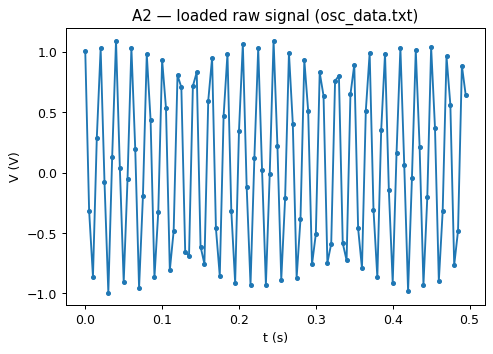

saved demo file to /var/folders/_t/bm9sptvd1lj4hqgnnvgzqffr0000gn/T/demo_out.txt
header lines: ['# Voltage vs time V(t), example data 2, exercise 2.\n', '# Voltage in Volts, time in seconds.\n', '# Colums: t, V(t)\n']
first parsed row: [0.      1.00276]
3 1.35 3.00e+08 1.234


In [72]:
import os, tempfile

d02 = np.loadtxt(f'{DATA}/osc_data.txt', delimiter=',', skiprows=3)
t_osc, V_osc = d02[:, 0], d02[:, 1]

plt.figure(figsize=(6, 4))
plt.plot(t_osc, V_osc, '.-')
plt.xlabel('t (s)'); plt.ylabel('V (V)')
plt.title('A2 — loaded raw signal (osc_data.txt)')
plt.show()

# --- saving (column layout, x/y/z as columns not rows) ---
tmp_path = os.path.join(tempfile.gettempdir(), 'demo_out.txt')
np.savetxt(tmp_path, np.array([t_osc, V_osc]).T, delimiter=',', header='t, V')
print("saved demo file to", tmp_path)

# --- manual line-by-line parsing (only if structure is irregular) ---
with open(f'{DATA}/osc_data.txt', 'r') as f:
    lines = f.readlines()
print("header lines:", lines[:3])
row = np.fromstring(lines[3], dtype=float, sep=',')
print("first parsed row:", row)

# --- number formatting ---
print('{:d}'.format(3), '{:0.2f}'.format(1.35), '{:.2e}'.format(3e8), f'{1.234:.3f}')


**Notes**
- This course uses **only** `np.loadtxt`/`np.savetxt` for the physics exercises (pandas is used in the ML notebooks Ex12–14, see Part D).
- Default delimiter is whitespace; pass `delimiter=','` for CSV.
- `np.loadtxt` chokes on irregular metadata lines — skip with `skiprows=N` or `comments='#'`.
- `np.savetxt('f.txt', (x,y,z))` writes rows, not columns — transpose (`np.array([x,y,z]).T`) for column layout.


## A3. Measurement Resolution & Sampling Rate

$$f_s = \frac{1}{\Delta t}, \qquad f_{Nyquist} = \frac{f_s}{2}, \qquad \Delta f = \frac{1}{N\Delta t}$$

Aliasing: a signal sampled too slowly relative to its true frequency is indistinguishable from a lower-frequency oscillation.


sample rate: 200.00 Hz (robust: 200.00 Hz)
extracted resolution of V1: 10.00 mV


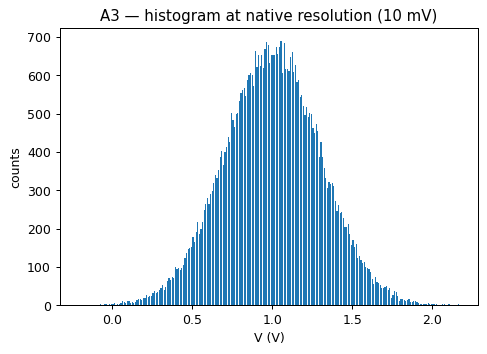

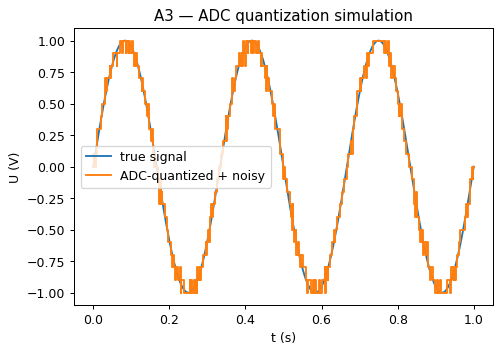

In [73]:
# --- sampling rate from a time vector (osc_data.txt, loaded in A2) ---
sample_rate = 1 / (t_osc[1] - t_osc[0])
sample_rate_robust = 1 / np.mean(np.diff(t_osc))
print(f"sample rate: {sample_rate:.2f} Hz (robust: {sample_rate_robust:.2f} Hz)")

# --- measurement resolution: smallest nonzero gap between distinct values ---
def extract_resolution(measured_values):
    sorted_values = np.sort(measured_values)
    sorted_diffs = np.sort(np.abs(np.diff(sorted_values)))
    tolerance = np.max(np.abs(measured_values)) * 1e-10
    for diff in sorted_diffs:
        if diff > tolerance:
            return diff
    return -1

pmf_raw = np.loadtxt(f'{DATA}/voltages_pmf.txt', skiprows=1)
t_v, V1, V2 = pmf_raw[0], pmf_raw[1], pmf_raw[2]     # two independent voltage datasets
resolution = extract_resolution(V1)
print(f"extracted resolution of V1: {resolution*1000:.2f} mV")

# --- histogram with bin size tied to the resolution ---
bin_edges = np.arange(V1.min(), V1.max() + resolution, resolution)
hist, _ = np.histogram(V1, bins=bin_edges)
bin_centers = bin_edges[:-1] + 0.5 * resolution

plt.figure(figsize=(6, 4))
plt.bar(bin_centers, hist, width=resolution * 0.8)
plt.xlabel('V (V)'); plt.ylabel('counts')
plt.title(f'A3 — histogram at native resolution ({resolution*1000:.0f} mV)')
plt.show()

# --- ADC quantization simulation ---
t_sim = np.linspace(0, 1, 500)
U_signal = np.sin(2 * np.pi * 3 * t_sim)
U_min, U_max, U_noise = 0.1, 1.0, 0.05
U_mess = np.clip(U_min * np.round((U_signal + np.random.normal(0, U_noise, t_sim.size)) / U_min), -U_max, U_max)

plt.figure(figsize=(6, 4))
plt.plot(t_sim, U_signal, label='true signal')
plt.plot(t_sim, U_mess, drawstyle='steps-mid', label='ADC-quantized + noisy')
plt.xlabel('t (s)'); plt.ylabel('U (V)'); plt.legend()
plt.title('A3 — ADC quantization simulation')
plt.show()


**Notes**
- If `binsize < resolution`, histograms get artifact/empty bins; choose `binsize >= resolution`.
- A dataset undersampled relative to another can plot **identically** to a slower oscillation — true frequency becomes unrecoverable (aliasing).


## A4. Mean, Standard Deviation & Standard Error of the Mean (SEM)

$$\mu=\frac1N\sum_i x_i,\quad
\sigma_{\text{pop}}=\sqrt{\tfrac1N\sum_i(x_i-\mu)^2}\ (\texttt{ddof=0}),\quad
\sigma_{\text{sample}}=\sqrt{\tfrac1{N-1}\sum_i(x_i-\mu)^2}\ (\texttt{ddof=1})$$

$$\mathrm{SEM}=\sigma_{\bar x}=\frac{\sigma}{\sqrt N}$$


mean=42.01908 V, sigma(ddof=1)=7.99222 V, SEM=5.65e-02 V


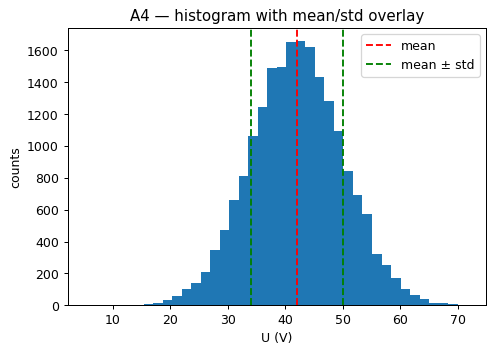

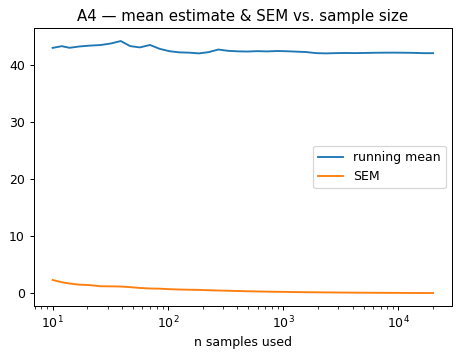

In [74]:
vt = np.loadtxt(f'{DATA}/voltage_timeseries.txt', delimiter=',', skiprows=1)
t_vt, U_vt = vt[0], vt[1]

mu = np.mean(U_vt)
sigma_pop = np.std(U_vt)            # ddof=0 (population)
sigma_sample = np.std(U_vt, ddof=1) # ddof=1 (unbiased sample estimate)
sem = sigma_sample / np.sqrt(len(U_vt))
print(f"mean={mu:.5f} V, sigma(ddof=1)={sigma_sample:.5f} V, SEM={sem:.2e} V")

hist, edges = np.histogram(U_vt, bins=40)
centers = edges[:-1] + np.diff(edges) / 2
plt.figure(figsize=(6, 4))
plt.bar(centers, hist, width=np.diff(edges), align='center')
plt.axvline(mu, color='r', linestyle='--', label='mean')
plt.axvline(mu - sigma_sample, color='g', linestyle='--', label='mean ± std')
plt.axvline(mu + sigma_sample, color='g', linestyle='--')
plt.xlabel('U (V)'); plt.ylabel('counts'); plt.legend()
plt.title('A4 — histogram with mean/std overlay')
plt.show()

# SEM shrinks like 1/sqrt(n); the raw std of the data does NOT shrink with n
n_values = np.unique(np.logspace(1, np.log10(len(U_vt)), 40).astype(int))
means = [np.mean(U_vt[:n]) for n in n_values]
sems  = [np.std(U_vt[:n], ddof=1) / np.sqrt(n) for n in n_values]

plt.figure(figsize=(6, 4))
plt.semilogx(n_values, means, label='running mean')
plt.semilogx(n_values, sems, label='SEM')
plt.xlabel('n samples used'); plt.legend()
plt.title('A4 — mean estimate & SEM vs. sample size')
plt.show()


**Notes**
- `np.std`/`np.var` default to `ddof=0`. Use `ddof=1` for the unbiased sample estimate (Bessel's correction) — matches the SEM formula above.
- SEM describes how precisely you know the **mean**, not the spread of individual points.


## A5. Gaussian Error Propagation (Fehlerfortpflanzung)

For $f(x_1,\dots,x_n)$ with independent uncertainties $\sigma_{x_i}$:

$$\sigma_f=\sqrt{\sum_i\left(\frac{\partial f}{\partial x_i}\right)^2\sigma_{x_i}^2}$$

Worked example, centripetal force $F=\frac{mv^2}{R}$:

$$\frac{\partial F}{\partial m}=\frac{v^2}{R},\quad\frac{\partial F}{\partial v}=\frac{2mv}{R},\quad\frac{\partial F}{\partial R}=-\frac{mv^2}{R^2}$$

SEM as a special case: $\bar x=\frac1N\sum x_i$ with shared $\sigma$ gives $\partial\bar x/\partial x_i = 1/N$, so
$\sigma_{\bar x}^2=N\cdot(\sigma/N)^2=\sigma^2/N \Rightarrow \sigma_{\bar x}=\sigma/\sqrt N$.


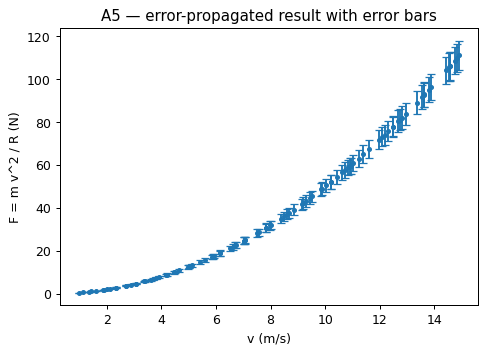

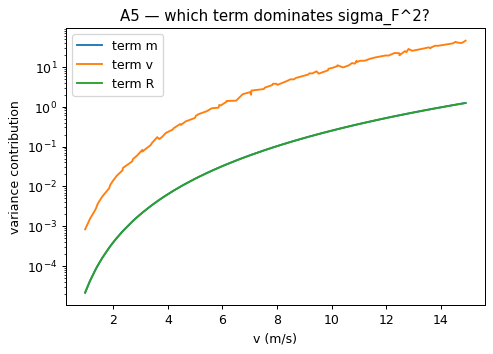

In [75]:
gv = np.loadtxt(f'{DATA}/geschwindigkeiten.txt', skiprows=3)
v, sigma_v = gv[0], gv[1]           # 100 velocity measurements + their individual uncertainties

m, sigma_m = 1.0, 0.01              # kg, example fixed mass + uncertainty
R, sigma_R = 2.0, 0.02              # m,  example fixed radius + uncertainty

F = m * v**2 / R
dF_dm = v**2 / R
dF_dv = 2 * m * v / R
dF_dR = -m * v**2 / R**2

term_m = (dF_dm * sigma_m)**2
term_v = (dF_dv * sigma_v)**2
term_R = (dF_dR * sigma_R)**2
sigma_F = np.sqrt(term_m + term_v + term_R)

plt.figure(figsize=(6, 4))
plt.errorbar(v, F, yerr=sigma_F, fmt='o', capsize=3, ms=3)
plt.xlabel('v (m/s)'); plt.ylabel('F = m v^2 / R (N)')
plt.title('A5 — error-propagated result with error bars')
plt.show()

order = np.argsort(v)
plt.figure(figsize=(6, 4))
plt.semilogy(v[order], term_m[order], label='term m')
plt.semilogy(v[order], term_v[order], label='term v')
plt.semilogy(v[order], term_R[order], label='term R')
plt.xlabel('v (m/s)'); plt.ylabel('variance contribution'); plt.legend()
plt.title('A5 — which term dominates sigma_F^2?')
plt.show()


**Notes**
- Square each `(partial derivative × sigma)` term, sum, **then** sqrt — never sum sigmas linearly.
- Assumes **uncorrelated** inputs (no covariance cross-terms).
- Only analytic (hand-derived) partial derivatives are used in this course.


---
# Part B — Signal Processing (Ex05–Ex07)
---

## B1. Covariance & Pearson Correlation Coefficient

$$\sigma_{xy}=\frac1{N-1}\sum_{i=0}^{N-1}(x_i-\bar x)(y_i-\bar y), \qquad \rho_{xy}=\frac{\sigma_{xy}}{\sigma_x\sigma_y}$$

`np.cov(x, y)` returns the full matrix `[[σxx, σxy],[σyx, σyy]]`; `np.corrcoef(x, y)` likewise.


rho(x,y) = 0.3243  (np.corrcoef: 0.3243)


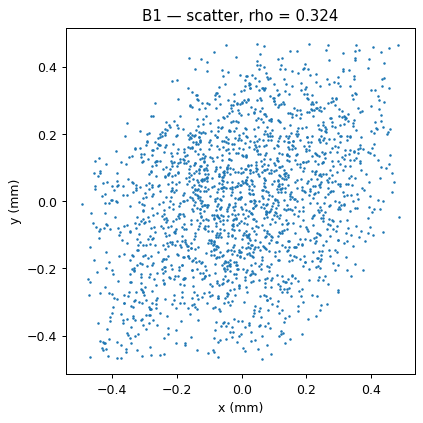

In [76]:
dxyz = np.loadtxt(f'{DATA}/data_xyz.txt', skiprows=2)
t_xyz, x_xyz, y_xyz, z_xyz = dxyz[:, 0], dxyz[:, 1], dxyz[:, 2], dxyz[:, 3]

def cov(x, y):
    N = len(x)
    return np.sum((x - np.mean(x)) * (y - np.mean(y))) / (N - 1)   # ddof=1, matches np.cov

sigma_x, sigma_y = np.sqrt(cov(x_xyz, x_xyz)), np.sqrt(cov(y_xyz, y_xyz))
rho_xy = cov(x_xyz, y_xyz) / (sigma_x * sigma_y)
print(f"rho(x,y) = {rho_xy:.4f}  (np.corrcoef: {np.corrcoef(x_xyz, y_xyz)[0,1]:.4f})")

plt.figure(figsize=(5, 5))
plt.plot(x_xyz, y_xyz, '.', ms=2)
plt.xlabel('x (mm)'); plt.ylabel('y (mm)')
plt.title(f'B1 — scatter, rho = {rho_xy:.3f}')
plt.show()


**Notes**
- `np.cov` uses `ddof=1` (divide by `N-1`).
- Always eyeball a scatter plot before trusting `ρ`.


## B2. Autocovariance / Autocorrelation

$$R_{xx}(\Delta i)=\frac{1}{N-\Delta i}\sum_{i=0}^{N-\Delta i-1}(x_i-\bar x)(x_{i+\Delta i}-\bar x), \qquad \tau=\Delta i\cdot\Delta t$$

$R_{xx}(0)=\mathrm{Var}(x)$.


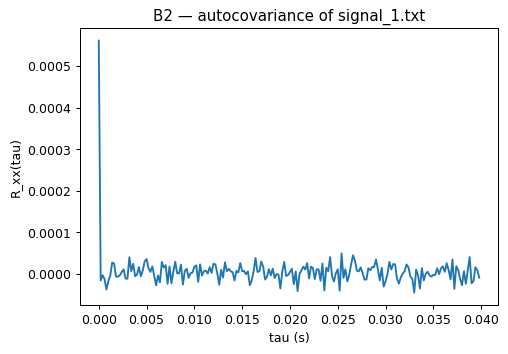

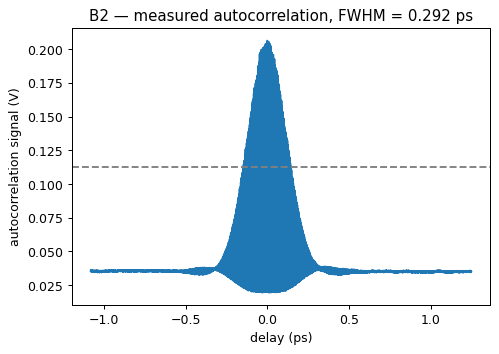

In [77]:
s1 = np.loadtxt(f'{DATA}/signal_1.txt', skiprows=2)
t_s1, amp_s1 = s1[:, 0], s1[:, 1]

def auto_cov(x, delta):
    N = len(x)                      # compute N locally, not from a global!
    if delta == 0:
        return np.var(x)            # x[:-0] would be empty -> special-case
    xr = x - np.mean(x)
    return np.sum(xr[:-delta] * xr[delta:]) / (N - delta)

dt_s1 = t_s1[1] - t_s1[0]
max_lag = 200
tau = np.arange(0, max_lag) * dt_s1
r_xx = np.array([auto_cov(amp_s1, d) for d in range(max_lag)])

plt.figure(figsize=(6, 4))
plt.plot(tau, r_xx)
plt.xlabel('tau (s)'); plt.ylabel('R_xx(tau)')
plt.title('B2 — autocovariance of signal_1.txt')
plt.show()

# real measured autocorrelation trace (has a baseline offset) + FWHM
laser = np.loadtxt(f'{DATA}/autocorrelation_laser.txt', skiprows=2)
delay, intensity = laser[:, 0], laser[:, 1]

def FWHM_baseline(x, y):
    half = (np.max(y) + np.min(y)) / 2
    idx = np.where(y >= half)[0]
    return abs(x[idx[-1]] - x[idx[0]]), half

fwhm, half_level = FWHM_baseline(delay, intensity)
plt.figure(figsize=(6, 4))
plt.plot(delay, intensity)
plt.axhline(half_level, color='gray', ls='--')
plt.xlabel('delay (ps)'); plt.ylabel('autocorrelation signal (V)')
plt.title(f'B2 — measured autocorrelation, FWHM = {fwhm:.3f} ps')
plt.show()


**Notes**
- Periodic signal → oscillating $R_{xx}(\tau)$ with same period. Pure noise → spike at $\tau=0$, ~0 elsewhere.
- `delta` is an index shift; convert to time via `tau = delta * dt`.


## B3. Discrete Fourier Transform (`np.fft`)

$$X_n=\sum_{k=0}^{N-1}x_k e^{-i2\pi kn/N}\ (\text{`np.fft.fft`, unnormalized}), \qquad a_n=\frac{X_n}{N}\ (\text{physical amplitude})$$

$$f_n=\frac{n}{N\Delta t}, \qquad f_{Nyquist}=\frac{1}{2\Delta t}, \qquad \Delta f=\frac{1}{N\Delta t}=\frac1{T_{tot}}$$


f_sample=150.0 Hz, f_nyquist=75.0 Hz, f_res=0.100 Hz
dominant frequency: 0.50 Hz


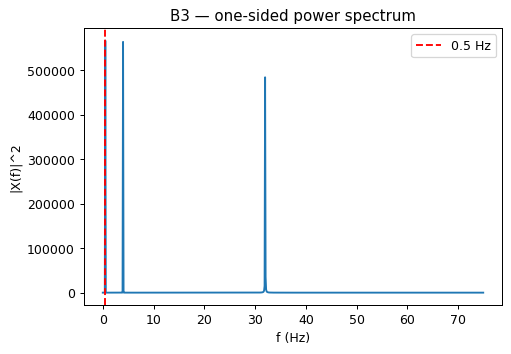

In [78]:
sig_data = np.loadtxt(f'{DATA}/signal.txt', skiprows=1)
t_sig, V_sig = sig_data[0], sig_data[1]
dt = t_sig[1] - t_sig[0]
N = len(t_sig)
f_sample, f_nyquist, f_res = 1/dt, 1/(2*dt), 1/(t_sig[-1]-t_sig[0])
print(f"f_sample={f_sample:.1f} Hz, f_nyquist={f_nyquist:.1f} Hz, f_res={f_res:.3f} Hz")

spectrum = np.fft.fft(V_sig)          # complex, UNnormalized (no 1/N)
freqs = np.fft.fftfreq(N, d=dt)
power = np.abs(spectrum)**2
mask = freqs >= 0

dominant_freq = freqs[mask][np.argmax(power[mask][1:]) + 1]   # skip DC bin
print(f"dominant frequency: {dominant_freq:.2f} Hz")

plt.figure(figsize=(6, 4))
plt.plot(freqs[mask], power[mask])
plt.axvline(dominant_freq, color='r', ls='--', label=f'{dominant_freq:.1f} Hz')
plt.xlabel('f (Hz)'); plt.ylabel('|X(f)|^2'); plt.legend()
plt.title('B3 — one-sided power spectrum')
plt.show()


**Notes**
- `fft` does not divide by `N`; the `1/N` sits in `ifft`.
- `fftfreq` order: `[0, f1, ..., f_{N/2-1}, -f_{N/2}, ..., -f1]`.
- Real signal ⇒ Hermitian-symmetric spectrum — filters must act on `np.abs(freq)`.


## B4. Fourier Synthesis

Square wave from odd harmonics: $U(t)=\sum_{n=1,3,5,\dots} a_n\sin(2\pi f_n t)$, $f_n=n/T$, $a_n=\frac{4}{\pi n}$ ($n$ odd), $0$ ($n$ even).


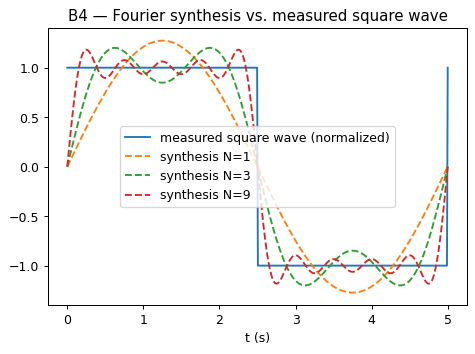

In [79]:
sq_data = np.loadtxt(f'{DATA}/square.txt', skiprows=1)
t_sq, V_sq = sq_data[0], sq_data[1]
T_sq = t_sq[-1] - t_sq[0]

def U_synth(t, N, T):
    result = np.zeros(len(t))
    for n in range(1, N + 1, 2):          # odd harmonics only
        result += (4 / (np.pi * n)) * np.sin(2 * np.pi * n * (1/T) * t)
    return result

plt.figure(figsize=(6, 4))
plt.plot(t_sq, V_sq / np.max(np.abs(V_sq)), label='measured square wave (normalized)')
for Nh in [1, 3, 9]:
    plt.plot(t_sq, U_synth(t_sq, Nh, T_sq), '--', label=f'synthesis N={Nh}')
plt.xlabel('t (s)'); plt.legend()
plt.title('B4 — Fourier synthesis vs. measured square wave')
plt.show()


## B5. Parseval's Theorem

$$\mathrm{Var}(x)=\sum_n \mathrm{PSD}(f_n)\,\Delta f \quad\text{(one-sided, density-scaled PSD)}$$

If measurement = signal + independent noise: $\mathrm{Var}(U_{mess})\approx\mathrm{Var}(x)+\mathrm{Var}(\text{noise})$.


Var(direct)=1.7441   Var(Parseval)=1.7441
Var(signal)+Var(noise) = 1.7555  (independence check, ~= Var(direct))


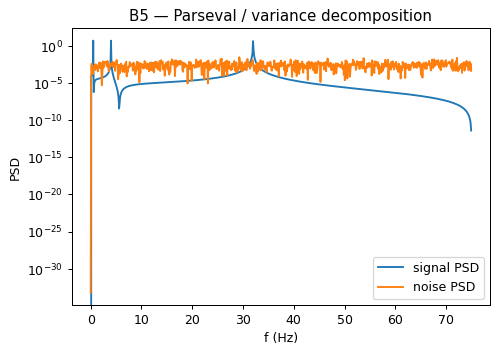

In [80]:
noise = np.random.normal(0, 0.5, V_sig.size)
U_mess = V_sig + noise

f_p, psd = signal.periodogram(U_mess, 1/dt, return_onesided=True, scaling='density')
variance_direct = np.var(U_mess)
variance_parseval = np.sum(psd) * (f_p[2] - f_p[1])
print(f"Var(direct)={variance_direct:.4f}   Var(Parseval)={variance_parseval:.4f}")

f_x, psd_x = signal.periodogram(V_sig, 1/dt, return_onesided=True, scaling='density')
f_n, psd_n = signal.periodogram(noise,  1/dt, return_onesided=True, scaling='density')
variance_combined = np.sum(psd_x) * (f_x[1]-f_x[0]) + np.sum(psd_n) * (f_n[1]-f_n[0])
print(f"Var(signal)+Var(noise) = {variance_combined:.4f}  (independence check, ~= Var(direct))")

plt.figure(figsize=(6, 4))
plt.semilogy(f_x, psd_x, label='signal PSD')
plt.semilogy(f_n, psd_n, label='noise PSD')
plt.xlabel('f (Hz)'); plt.ylabel('PSD'); plt.legend()
plt.title('B5 — Parseval / variance decomposition')
plt.show()


**Notes**
- `scipy.signal.periodogram(..., return_onesided=True, scaling='density')` handles the ×2 folding — `sum(psd)·Δf` matches `np.var` directly.


## B6. Filtering

### Moving average (boxcar smoothing, time domain) = low-pass filter

$$\tilde x_i = \mathrm{mean}(x_{i-\Delta},\dots,x_{i+\Delta})$$


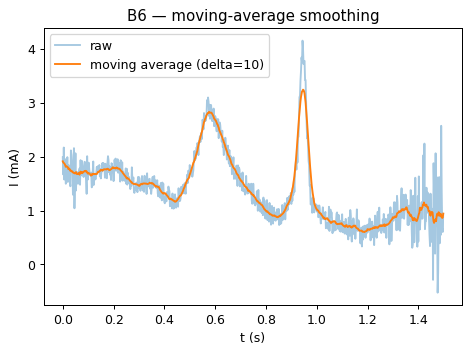

In [81]:
pk = np.loadtxt(f'{DATA}/peaks.txt', skiprows=2)
t_pk, I_pk = pk[:, 0], pk[:, 1]

def moving_average(x, delta, edges='repeat'):
    N = len(x)
    if edges == 'repeat':
        padded = np.concatenate([np.ones(delta)*x[0], x, np.ones(delta)*x[-1]])
    elif edges == 'cut':
        padded = np.concatenate([np.zeros(delta), x, np.zeros(delta)])
    elif edges == 'wrap':
        padded = np.concatenate([x[-delta:], x, x[:delta]])
    filtered = np.array([np.mean(padded[i:i+2*delta]) for i in range(N)])
    return filtered[delta:-delta] if edges == 'cut' else filtered

I_smooth = moving_average(I_pk, delta=10)

plt.figure(figsize=(6, 4))
plt.plot(t_pk, I_pk, alpha=0.4, label='raw')
plt.plot(t_pk, I_smooth, label='moving average (delta=10)')
plt.xlabel('t (s)'); plt.ylabel('I (mA)'); plt.legend()
plt.title('B6 — moving-average smoothing')
plt.show()


**Notes**
- Never apply `moving_average` directly to a complex FFT spectrum — smooth `|X|`/PSD, or Re/Im separately.

### Frequency-domain filtering (low/high/band-pass by zeroing FFT bins)

FFT → zero unwanted bins → IFFT → take `.real`.


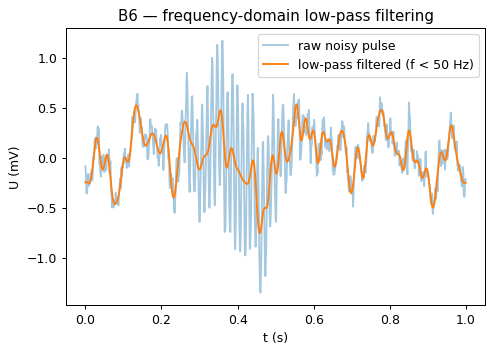

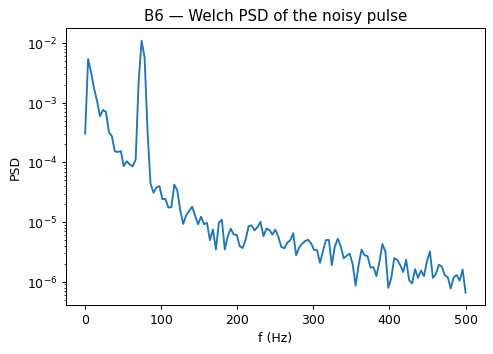

In [82]:
npz = np.loadtxt(f'{DATA}/noisy_pulse.txt', skiprows=2)
t_np_, U_np_ = npz[:, 0], npz[:, 1]

def frequency_filter(sig, t, f_min, f_max):
    dt_, N_ = t[1]-t[0], len(t)
    freq = np.fft.fftfreq(N_, d=dt_)
    spectrum = np.fft.fft(sig).copy()
    mask = (np.abs(freq) >= f_min) & (np.abs(freq) <= f_max)   # keep this band
    spectrum[~mask] = 0
    return np.fft.ifft(spectrum).real

f_cut = 50.0   # Hz, envelope cutoff (pick below the carrier frequency, read off a PSD plot)
envelope = frequency_filter(U_np_, t_np_, 0, f_cut)

plt.figure(figsize=(6, 4))
plt.plot(t_np_, U_np_, alpha=0.4, label='raw noisy pulse')
plt.plot(t_np_, envelope, label=f'low-pass filtered (f < {f_cut:.0f} Hz)')
plt.xlabel('t (s)'); plt.ylabel('U (mV)'); plt.legend()
plt.title('B6 — frequency-domain low-pass filtering')
plt.show()

f_w, Pxx_w = signal.welch(U_np_, fs=1/(t_np_[1]-t_np_[0]), nperseg=256)
plt.figure(figsize=(6, 4))
plt.semilogy(f_w, Pxx_w)
plt.xlabel('f (Hz)'); plt.ylabel('PSD')
plt.title('B6 — Welch PSD of the noisy pulse')
plt.show()


**Notes**
- Must filter on `np.abs(freq)` (real signal has energy at ±f) — zeroing only positive bins breaks Hermitian symmetry.
- `ifft` output is complex due to float rounding — always take `.real`.
- `scipy.signal.welch` averages multiple segments -> smoother PSD estimate than a raw periodogram.


---
# Part C — Probability & Fitting (Ex08–Ex11)
---

## C1. Empirical PMF from Data (binning)

Discretize into bins of width `resolution`; $p_i=n_i/M$, $\sum_i p_i=1$.


sum(px) = 1.0
mode=1.050 V, median=1.000 V, FWHM=0.660 V


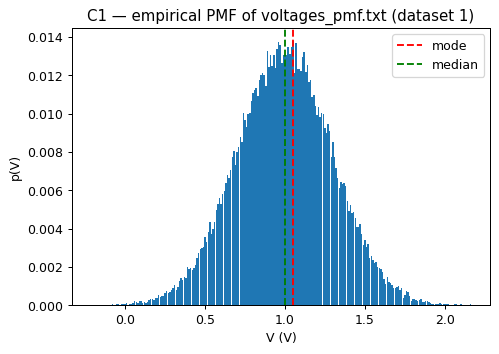

In [83]:
def PMF(data, resolution):
    bin_centers = np.arange(np.min(data), np.max(data) + resolution/1000, resolution)
    bin_edges = np.linspace(bin_centers[0]-resolution/2, bin_centers[-1]+resolution/2,
                             len(bin_centers)+1)
    hist, _ = np.histogram(data, bin_edges)
    return bin_centers, hist / np.sum(hist)         # sanity check: sum(px) == 1

def mode(data, resolution):
    x, px = PMF(data, resolution)
    return x[np.argmax(px)]

def median_sort(data):                    # exact median via sorting
    s = np.sort(data); n = len(data)
    return s[n//2] if n % 2 else (s[n//2] + s[n//2-1]) / 2

def FWHM(x, y):
    idx = np.where(y >= np.max(y)/2)[0]
    return abs(x[idx[-1]] - x[idx[0]])

# reuse V1 (loaded in A3) -- one of the two voltages_pmf.txt datasets
x_pmf, px_pmf = PMF(V1, resolution)
print("sum(px) =", np.sum(px_pmf))

mode_v1, median_v1, fwhm_v1 = mode(V1, resolution), median_sort(V1), FWHM(x_pmf, px_pmf)
print(f"mode={mode_v1:.3f} V, median={median_v1:.3f} V, FWHM={fwhm_v1:.3f} V")

plt.figure(figsize=(6, 4))
plt.bar(x_pmf, px_pmf, width=resolution*0.9)
plt.axvline(mode_v1, color='r', ls='--', label='mode')
plt.axvline(median_v1, color='g', ls='--', label='median')
plt.xlabel('V (V)'); plt.ylabel('p(V)'); plt.legend()
plt.title('C1 — empirical PMF of voltages_pmf.txt (dataset 1)')
plt.show()


## C2. Moments (raw & central) from Data

$$m_n=\frac1M\sum_j X_j^n\ \text{(raw)}, \qquad \mu_n=\frac1M\sum_j(X_j-\bar X)^n\ \text{(central)}$$

$\mu_1\approx0$ (sanity check), $\mu_2=\mathrm{Var}$, skewness $=\mu_3/\sigma^3$, excess kurtosis $=\mu_4/\sigma^4-3$ (0 for Gaussian).


mean=1738.2 d, std=442.8 d, skew=2.71, excess kurtosis=14.62


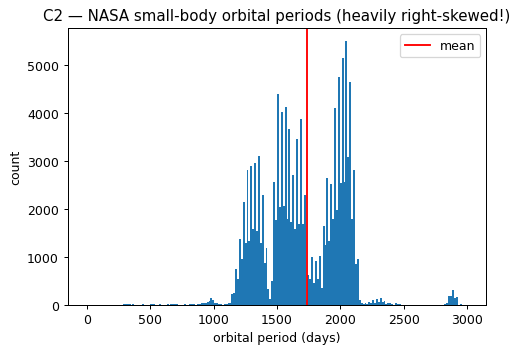

In [84]:
periods = np.loadtxt(f'{DATA}/nasa_periods.txt', skiprows=1)   # NASA small-body orbital periods (days)

def moment(data, n):
    return np.sum(data**n) / len(data)

m1 = moment(periods, 1)
variance = moment(periods - m1, 2)          # 2nd CENTRAL moment
sigma_p = np.sqrt(variance)
skewness = moment(periods - m1, 3) / sigma_p**3
kurtosis = moment(periods - m1, 4) / sigma_p**4 - 3
print(f"mean={m1:.1f} d, std={sigma_p:.1f} d, skew={skewness:.2f}, excess kurtosis={kurtosis:.2f}")

plt.figure(figsize=(6, 4))
plt.hist(periods, bins=200, range=(0, 3000))
plt.axvline(m1, color='r', label='mean')
plt.xlabel('orbital period (days)'); plt.ylabel('count'); plt.legend()
plt.title('C2 — NASA small-body orbital periods (heavily right-skewed!)')
plt.show()


**Notes**
- mean = 1st raw moment; variance = 2nd **central** moment (`Var = m2 - m1^2` if only raw moments are known).
- A large positive skew (as here) flags a long right tail — very non-Gaussian.

## C3. Normal Distribution (manual)

$$f(x)=\frac{1}{\sqrt{2\pi\sigma^2}}\exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

Multiply density by `binsize` to compare against a binned PMF.


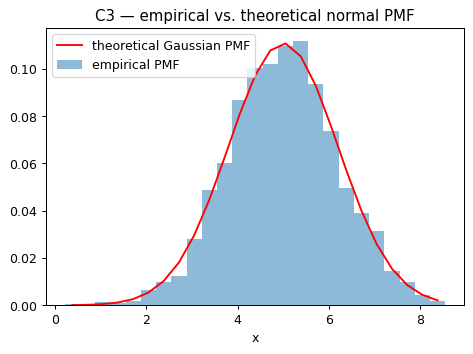

In [85]:
mu_n, sigma_n = 5.0, 1.2
data_n = np.random.normal(mu_n, sigma_n, 2000)

def normal_pmf(x, mu, sigma, binsize):
    return (1/np.sqrt(2*np.pi*sigma**2)) * np.exp(-0.5*((x-mu)/sigma)**2) * binsize

resolution_n = 3.5 * sigma_n / len(data_n)**(1/3)      # bin-width heuristic
x_n, empirical_px = PMF(data_n, resolution_n)
theoretical_px = normal_pmf(x_n, mu_n, sigma_n, resolution_n)

plt.figure(figsize=(6, 4))
plt.bar(x_n, empirical_px, width=resolution_n, alpha=0.5, label='empirical PMF')
plt.plot(x_n, theoretical_px, 'r-', label='theoretical Gaussian PMF')
plt.xlabel('x'); plt.legend()
plt.title('C3 — empirical vs. theoretical normal PMF')
plt.show()


## C4. Central Limit Theorem

Sample-mean distribution $\to\mathcal N(\mu,\ \sigma/\sqrt n)$ as sample size $n$ grows — even when the
underlying data (here: the skewed NASA orbital periods from C2) is far from Gaussian.


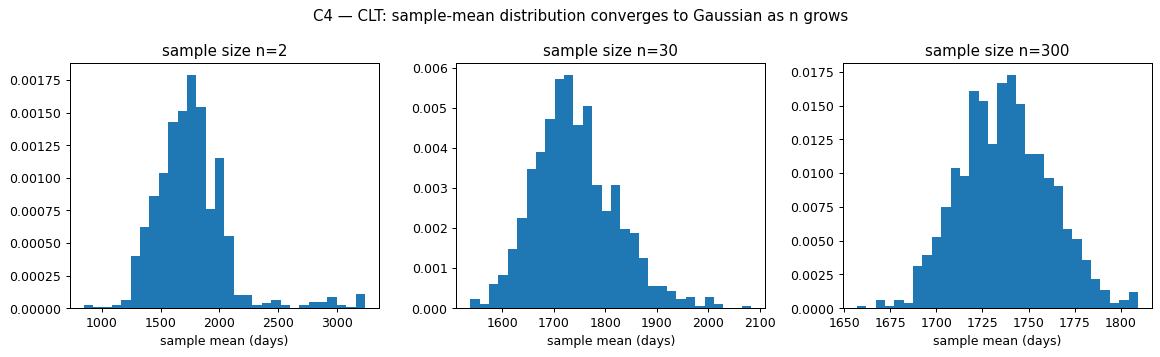

In [86]:
def draw_central_limit_data(data, num_samples, sample_size):
    means = [np.mean(np.random.choice(data, size=sample_size, replace=True))
             for _ in range(num_samples)]
    return np.array(means)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, n in zip(axes, [2, 30, 300]):
    means_n = draw_central_limit_data(periods, num_samples=1000, sample_size=n)
    ax.hist(means_n, bins=30, density=True)
    ax.set_title(f'sample size n={n}')
    ax.set_xlabel('sample mean (days)')
plt.suptitle('C4 — CLT: sample-mean distribution converges to Gaussian as n grows')
plt.tight_layout()
plt.show()


## C5. Linear / Polynomial Least-Squares Fitting

$$S=\sum_i\frac{(y_i-f(x_i,\vec a))^2}{\sigma_i^2}\quad(=\chi^2),\qquad f(x,\vec a)=\sum_{n=0}^m a_n x^n$$

Weighted normal equations ($w_i=1/\sigma_i^2$), straight line:

$$N=\begin{pmatrix}\sum w_i & \sum w_ix_i\\ \sum w_ix_i & \sum w_ix_i^2\end{pmatrix},\ \vec Y=\begin{pmatrix}\sum w_iy_i\\ \sum w_ix_iy_i\end{pmatrix},\ \vec a=N^{-1}\vec Y,\ C=N^{-1}$$

Parameter uncertainties: $\sqrt{\mathrm{diag}(C)}$.


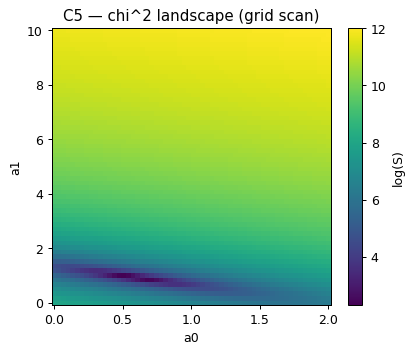

F(x) = (0.588+-0.063) + (0.939+-0.047) x


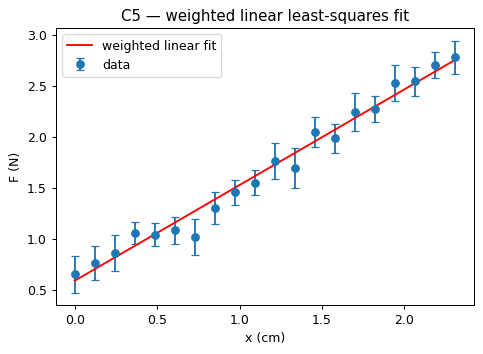

In [87]:
ld = np.loadtxt(f'{DATA}/lin_data.txt', skiprows=2)
x_l, F_l, sigma_F_l = ld[:, 0], ld[:, 1], ld[:, 2]

def Sres(x, y, sigma, a0, a1):
    return np.sum(((y - (a0 + a1*x)) / sigma) ** 2)

a0v, a1v = np.linspace(0, 2, 60), np.linspace(0, 10, 60)
S_matrix = np.array([[np.log(Sres(x_l, F_l, sigma_F_l, a0, a1)) for a1 in a1v] for a0 in a0v])

plt.figure(figsize=(5, 4))
plt.pcolormesh(a0v, a1v, S_matrix.T, shading='nearest')       # note the .T
plt.colorbar(label='log(S)')
plt.xlabel('a0'); plt.ylabel('a1')
plt.title('C5 — chi^2 landscape (grid scan)')
plt.show()

w = 1 / sigma_F_l**2
Nmat = np.array([[np.sum(w),        np.sum(w*x_l)],
                  [np.sum(w*x_l),   np.sum(w*x_l**2)]])
Yvec = np.array([np.sum(w*F_l), np.sum(w*x_l*F_l)])
C = np.linalg.inv(Nmat)
a = C @ Yvec
a_err = np.sqrt(np.diag(C))
print(f"F(x) = ({a[0]:.3f}+-{a_err[0]:.3f}) + ({a[1]:.3f}+-{a_err[1]:.3f}) x")

x_fit = np.linspace(x_l.min(), x_l.max(), 100)
plt.figure(figsize=(6, 4))
plt.errorbar(x_l, F_l, yerr=sigma_F_l, fmt='o', capsize=3, label='data')
plt.plot(x_fit, a[0] + a[1]*x_fit, 'r-', label='weighted linear fit')
plt.xlabel('x (cm)'); plt.ylabel('F (N)'); plt.legend()
plt.title('C5 — weighted linear least-squares fit')
plt.show()


reduced chi^2 = 20.44


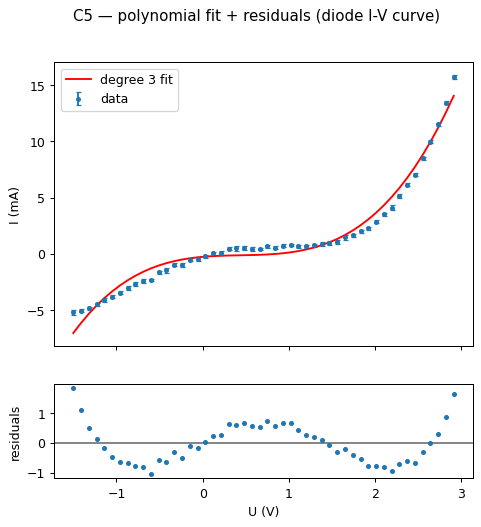

In [88]:
pdat = np.loadtxt(f'{DATA}/poly_data.txt', skiprows=1)
x_p, y_p, sigma_p_ = pdat[:, 0], pdat[:, 1], pdat[:, 2]

def poly_fit(x, y, sigma, m):
    w = 1 / sigma**2
    A = np.vander(x, N=m+1, increasing=True)         # columns: 1, x, x^2, ..., x^m
    Nmat = (A * w[:, None]).T @ A
    Yvec = (A * w[:, None]).T @ y
    C = np.linalg.inv(Nmat)
    return C @ Yvec, C

m_deg = 3
a_poly, C_poly = poly_fit(x_p, y_p, sigma_p_, m_deg)
y_fit = np.polyval(a_poly[::-1], x_p)          # polyval expects highest-order coeff first
residuals = y_p - y_fit
chi2_red = np.sum((residuals/sigma_p_)**2) / (len(x_p) - (m_deg+1))
print(f"reduced chi^2 = {chi2_red:.2f}")

order = np.argsort(x_p)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
ax1.errorbar(x_p, y_p, yerr=sigma_p_, fmt='o', ms=3, capsize=2, label='data')
ax1.plot(x_p[order], y_fit[order], 'r-', label=f'degree {m_deg} fit')
ax1.set_ylabel('I (mA)'); ax1.legend()
ax2.axhline(0, color='gray')
ax2.plot(x_p, residuals, '.')
ax2.set_xlabel('U (V)'); ax2.set_ylabel('residuals')
plt.suptitle('C5 — polynomial fit + residuals (diode I-V curve)')
plt.show()


**Notes**
- Reduced $\chi^2_\nu=S/(N_{points}-(m+1))\approx1$ is good; $\gg1$ underfit; $\ll1$ overfit/overestimated errors.
- Structure in residuals ⇒ underfitting; residuals fitting the noise (high-order poly) ⇒ overfitting.
- `N^{-1}` **is** the parameter covariance matrix when $w_i=1/\sigma_i^2$.

## C6. Nonlinear Fitting with `scipy.optimize.curve_fit`


A=6.2183+-0.3092   tau=0.2436+-0.0183


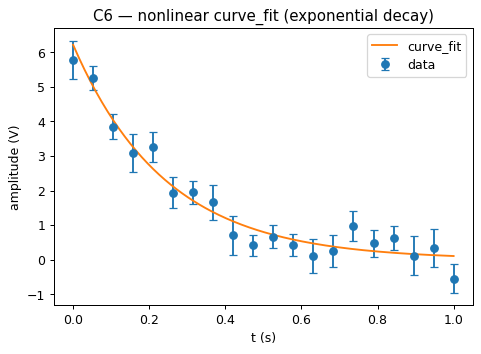

In [89]:
dc = np.loadtxt(f'{DATA}/decay.txt', skiprows=1)
time_d, amp_d, err_d = dc[0], dc[1], dc[2]

def f_fit(x, A, tau):                 # params passed individually, not as a vector
    return A * np.exp(-x / tau)

popt, pcov = curve_fit(f_fit, time_d, amp_d, sigma=err_d, p0=[6.0, 0.3])
perr = np.sqrt(np.diag(pcov))         # 1-sigma uncertainties, NEVER pcov directly
print(f"A={popt[0]:.4f}+-{perr[0]:.4f}   tau={popt[1]:.4f}+-{perr[1]:.4f}")

t_fine = np.linspace(time_d.min(), time_d.max(), 200)
plt.figure(figsize=(6, 4))
plt.errorbar(time_d, amp_d, err_d, fmt='o', capsize=3, label='data')
plt.plot(t_fine, f_fit(t_fine, *popt), label='curve_fit')
plt.xlabel('t (s)'); plt.ylabel('amplitude (V)'); plt.legend()
plt.title('C6 — nonlinear curve_fit (exponential decay)')
plt.show()


**Notes**
- `sigma=` gives a proper $\chi^2$-weighted fit; `p0` (initial guess, from eyeballing a plot) matters for convergence.

## C7. Gradient Descent (for nonlinear least squares)

$$S(\vec a)=\sum_i\frac{(y_i-f(x_i,\vec a))^2}{\sigma_i^2}, \qquad
(\nabla S)_i=\frac{S(\vec a+\vec\Delta_i)-S(\vec a-\vec\Delta_i)}{2\Delta}\ \text{(central diff.)}$$

Update: $\vec a\leftarrow\vec a-\alpha\nabla S$ (basic) or $a_i \leftarrow a_i - \alpha\,(\partial^2S/\partial a_i^2)^{-1}\partial S/\partial a_i$ (Newton-scaled, using Hessian diagonal — converges far faster).


gradient descent: A=6.2183+-0.2352 tau=0.2436+-0.0137 (60 iters)


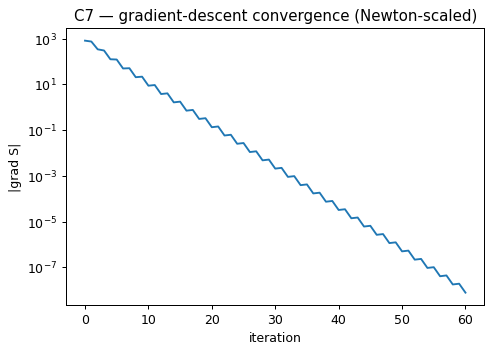

In [90]:
def Sres_gd(x, y, sigma, f, a):
    return np.sum((y - f(x, a))**2 / sigma**2)

def dS(x, y, sigma, f, a, delta):                    # numerical gradient
    grad = np.zeros(len(a))
    for i in range(len(a)):
        d = np.zeros(len(a)); d[i] = delta
        grad[i] = (Sres_gd(x,y,sigma,f,a+d) - Sres_gd(x,y,sigma,f,a-d)) / (2*delta)
    return grad

def dS2(x, y, sigma, f, a, delta):                   # numerical Hessian
    H = np.zeros((len(a), len(a)))
    for i in range(len(a)):
        for j in range(len(a)):
            di = np.zeros(len(a)); di[i] = delta
            dj = np.zeros(len(a)); dj[j] = delta
            H[i, j] = (Sres_gd(x,y,sigma,f,a+di+dj) - Sres_gd(x,y,sigma,f,a-di+dj)
                     - Sres_gd(x,y,sigma,f,a+di-dj) + Sres_gd(x,y,sigma,f,a-di-dj)) / (4*delta**2)
    return H

def gradient_descent(x, y, sigma, f, a0, delta, alpha, dS_min, i_max, scaled=False):
    a = a0.copy(); i = 0
    grad = dS(x, y, sigma, f, a, delta)
    norms = [np.linalg.norm(grad)]
    while np.linalg.norm(grad) > dS_min and i < int(i_max):
        if scaled:
            hess_diag = np.diag(dS2(x, y, sigma, f, a, delta))
            a = a - alpha * grad / hess_diag
        else:
            a = a - alpha * grad
        grad = dS(x, y, sigma, f, a, delta)
        norms.append(np.linalg.norm(grad))
        i += 1
    cov = np.linalg.inv(dS2(x, y, sigma, f, a, delta))    # parameter covariance at optimum
    return a, cov, norms, i

def f_model(x, a):
    return a[0] * np.exp(-x / a[1])

a_opt, cov_gd, norms, iters = gradient_descent(time_d, amp_d, err_d, f_model, a0=np.array([7.0, 0.3]),
                                                delta=1e-4, alpha=1.0, dS_min=1e-8, i_max=1e4, scaled=True)
a_err_gd = np.sqrt(np.diag(cov_gd))
print(f"gradient descent: A={a_opt[0]:.4f}+-{a_err_gd[0]:.4f} tau={a_opt[1]:.4f}+-{a_err_gd[1]:.4f} ({iters} iters)")

plt.figure(figsize=(6, 4))
plt.semilogy(norms)
plt.xlabel('iteration'); plt.ylabel('|grad S|')
plt.title('C7 — gradient-descent convergence (Newton-scaled)')
plt.show()


**Notes**
- Always cap iterations (`i_max`) as a fallback against divergence.
- Plain gradient descent needs a tiny `alpha` (~1e-6, ~1e5 iterations); Newton-scaled (`alpha=1`, divide by Hessian diagonal) converges in tens of iterations.
- Parameter uncertainties = `sqrt(diag(inv(Hessian)))` at the optimum — same recipe as `curve_fit`'s `pcov`.


---
# Part D — Machine Learning (Ex12–Ex14)
---

## D1. Multiple & Polynomial Linear Regression (Ex12, Advertising data)

$$\hat y=\beta_0+\beta_1x_1+\dots+\beta_px_p, \qquad R^2=1-\frac{SS_{res}}{SS_{tot}}=1-\frac{\sum(y_i-\hat y_i)^2}{\sum(y_i-\bar y)^2}$$

Ridge (L2): $\sum_i(y_i-\hat y_i)^2+\alpha\sum_j\beta_j^2$ (larger $\alpha$ = more shrinkage/less overfit, more bias). Standardization: $x'=(x-\mu)/\sigma$.


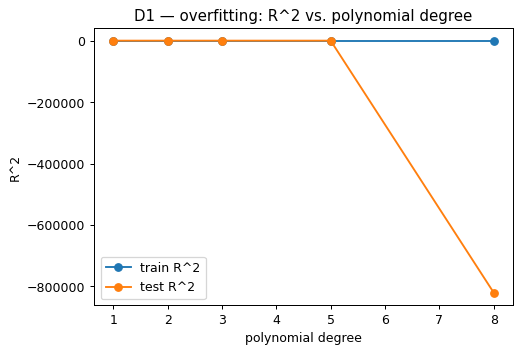

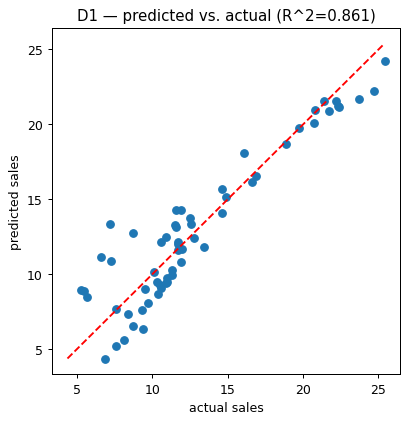

best alpha: {'alpha': 1}  best CV R^2: 0.9623321533195341


In [91]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score

df_ad = pd.read_csv(f'{DATA}/advertising.csv')
y_ad = df_ad['sales']; X_ad = df_ad.drop(columns=['sales'])
X_train, X_test, y_train, y_test = train_test_split(X_ad, y_ad, test_size=0.30, random_state=42)

scaler = StandardScaler().fit(X_train)              # fit ONLY on train
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

degrees = [1, 2, 3, 5, 8]
r2_train_list, r2_test_list = [], []
for deg in degrees:
    poly = PolynomialFeatures(degree=deg)
    Xtr_p, Xte_p = poly.fit_transform(X_train_s), poly.transform(X_test_s)
    lr = LinearRegression().fit(Xtr_p, y_train)
    r2_train_list.append(r2_score(y_train, lr.predict(Xtr_p)))
    r2_test_list.append(r2_score(y_test, lr.predict(Xte_p)))

plt.figure(figsize=(6, 4))
plt.plot(degrees, r2_train_list, 'o-', label='train R^2')
plt.plot(degrees, r2_test_list, 'o-', label='test R^2')
plt.xlabel('polynomial degree'); plt.ylabel('R^2'); plt.legend()
plt.title('D1 — overfitting: R^2 vs. polynomial degree')
plt.show()

# predicted-vs-actual diagnostic plot for the plain linear model
lr_final = LinearRegression().fit(X_train_s, y_train)
y_pred = lr_final.predict(X_test_s)

plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--')
plt.xlabel('actual sales'); plt.ylabel('predicted sales')
plt.title(f'D1 — predicted vs. actual (R^2={r2_score(y_test, y_pred):.3f})')
plt.show()

# Ridge + small hyperparameter search on the degree-3 features
X_poly3_train = PolynomialFeatures(degree=3).fit_transform(X_train_s)
grid = GridSearchCV(Ridge(), {'alpha': [0.01, 0.1, 1, 10, 100]}, cv=4).fit(X_poly3_train, y_train)
print("best alpha:", grid.best_params_, " best CV R^2:", grid.best_score_)


**Notes**
- `fit_transform` on train, `transform` (never re-fit) on test — no leakage.
- Higher polynomial degree → overfitting (train R² keeps rising, test R² eventually drops).

## D2. Classification: Logistic Regression, MLP, Manual Forward Pass (Ex13)

$$p=\sigma(w^\top x+b)=\frac1{1+e^{-(w^\top x+b)}}\ \text{(linear decision boundary)}, \qquad \text{accuracy}=\frac{\#\text{correct}}{\#\text{total}}$$


logistic regression accuracy: 0.967


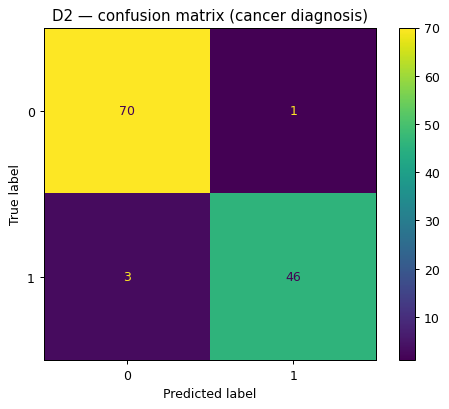

In [92]:
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

df_c = pd.read_csv(f'{DATA}/cancer.csv')
X_c = df_c.drop(columns=['diagnosis']); y_c = df_c['diagnosis']
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_c, y_c, test_size=0.30, random_state=42)
scaler_c = StandardScaler().fit(Xc_train)
Xc_train_s, Xc_test_s = scaler_c.transform(Xc_train), scaler_c.transform(Xc_test)

lr_c = LogisticRegression(max_iter=5000).fit(Xc_train_s, yc_train)
acc_c = accuracy_score(yc_test, lr_c.predict(Xc_test_s))
print(f"logistic regression accuracy: {acc_c:.3f}")

ConfusionMatrixDisplay.from_estimator(lr_c, Xc_test_s, yc_test)
plt.title('D2 — confusion matrix (cancer diagnosis)')
plt.show()


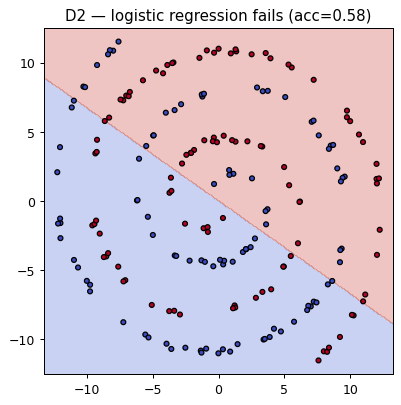

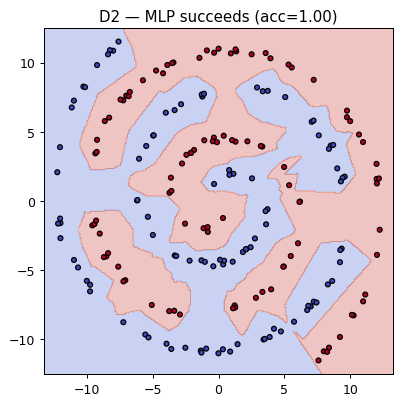

In [93]:
spiral_train = pd.read_csv(f'{DATA}/spiral_train.csv')
Xs, ys = spiral_train[['X1', 'X2']].values, spiral_train['y'].values

def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
    y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.figure(figsize=(5, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=15)
    plt.title(title)
    plt.show()

lr_s = LogisticRegression().fit(Xs, ys)
plot_decision_boundary(lr_s, Xs, ys, f'D2 — logistic regression fails (acc={lr_s.score(Xs, ys):.2f})')

mlp_s = MLPClassifier(hidden_layer_sizes=(20, 20), max_iter=5000, random_state=42).fit(Xs, ys)
plot_decision_boundary(mlp_s, Xs, ys, f'D2 — MLP succeeds (acc={mlp_s.score(Xs, ys):.2f})')


In [94]:
# --- manual NN forward pass ---
def relu_layer(x, W, b):
    return np.maximum(0, W @ x + b)

def sigmoid_layer(x, W, b):
    return 1 / (1 + np.exp(-(W @ x + b)))

def forward_pass(input_vector, weights, biases):     # weights, biases: python LISTS (layers can differ in shape)
    a = input_vector
    for W, b in zip(weights[:-1], biases[:-1]):       # all but last: ReLU
        a = relu_layer(a, W, b)
    return np.round(sigmoid_layer(a, weights[-1], biases[-1]))   # last layer: sigmoid, threshold to 0/1

testarray = np.arange(1, 5, dtype=float)
W1, b1 = np.ones((3, 4)), np.array([0., -10., -12.])
print("relu_layer:   ", relu_layer(testarray, W1, b1))
print("sigmoid_layer:", sigmoid_layer(testarray, W1, b1))


relu_layer:    [10.  0.  0.]
sigmoid_layer: [0.9999546  0.5        0.11920292]


**Notes**
- Logistic regression = linear decision boundary → fails on non-linearly-separable data (spirals); MLP with a nonlinear activation succeeds.
- This manual forward pass **is** `predict()` — training (fitting W, b) is a separate problem.

## D3. Data Cleaning + KNN / Decision Trees (Ex14, Titanic)

Euclidean distance: $d(p_1,p_2)=\sqrt{\sum_i(p_{1,i}-p_{2,i})^2}$.


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


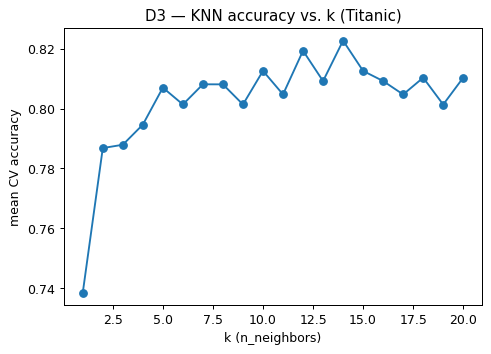

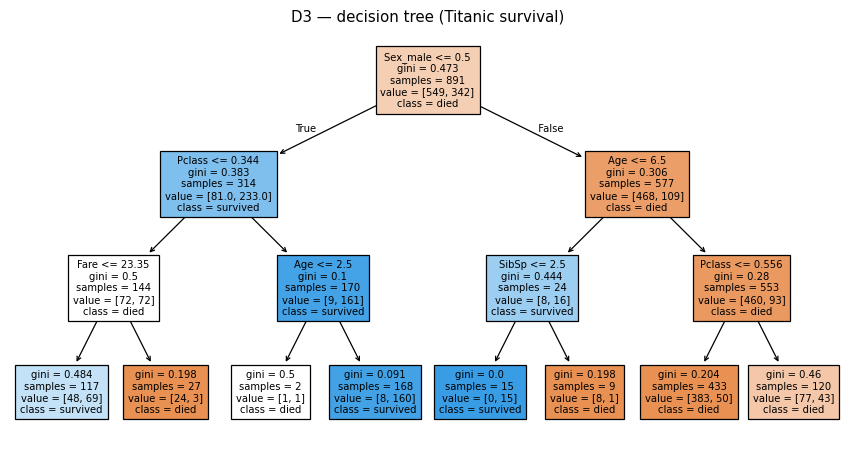

In [95]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree

df_t = pd.read_csv(f'{DATA}/titanic.csv')
df_t.info()

df_t = df_t.drop(columns=['Cabin'])                                  # >70% missing -> drop
df_t[['Age']] = SimpleImputer(strategy='mean').fit_transform(df_t[['Age']])            # double brackets -> 2D
df_t[['Embarked']] = SimpleImputer(strategy='most_frequent').fit_transform(df_t[['Embarked']])
df_t = df_t.drop(columns=['PassengerId', 'Name', 'Ticket'])           # no predictive signal

ohe = OneHotEncoder(drop='first', sparse_output=False)                # drop='first' avoids dummy trap
encoded = pd.DataFrame(ohe.fit_transform(df_t[['Sex', 'Embarked']]),
                        columns=ohe.get_feature_names_out(), index=df_t.index)
df_t = pd.concat([df_t.drop(columns=['Sex', 'Embarked']), encoded], axis=1)
df_t[['Pclass']] = TargetEncoder().fit_transform(df_t[['Pclass']], df_t['Survived'])   # mean-encode ordinal

X_t = df_t.drop(columns=['Survived']); y_t = df_t['Survived']

# KNN is distance-based -> MUST scale
X_t_scaled = StandardScaler().fit_transform(X_t)
k_values = range(1, 21)
cv_means = [cross_val_score(KNeighborsClassifier(n_neighbors=k), X_t_scaled, y_t, cv=5).mean() for k in k_values]

plt.figure(figsize=(6, 4))
plt.plot(list(k_values), cv_means, 'o-')
plt.xlabel('k (n_neighbors)'); plt.ylabel('mean CV accuracy')
plt.title('D3 — KNN accuracy vs. k (Titanic)')
plt.show()

# Decision tree is rule-based -> scaling NOT needed
best_dt = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_t, y_t)
plt.figure(figsize=(12, 6))
plot_tree(best_dt, max_depth=3, feature_names=X_t.columns, class_names=['died', 'survived'],
          filled=True, fontsize=8)
plt.title('D3 — decision tree (Titanic survival)')
plt.show()


**Notes**
- `SimpleImputer` needs 2D input → `df[['col']]`, not `df['col']`.
- Distance-based methods (KNN) need scaling; tree-based methods don't.

## D4. K-Means Clustering (from scratch)

Loop: (1) assign each point to nearest centroid, (2) recompute centroid as mean of assigned points, repeat until movement `< tol` or `max_iterations` reached.


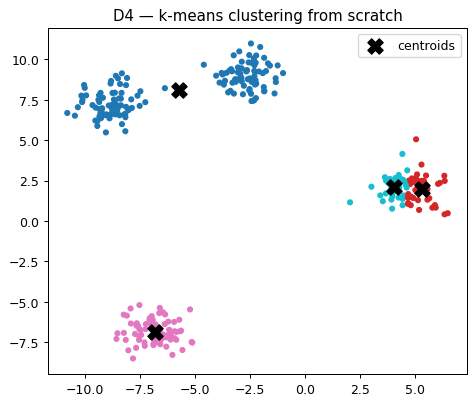

In [96]:
from sklearn.datasets import make_blobs

def euclidean_distance(p1, p2):
    return np.sqrt(np.sum((p1 - p2) ** 2))

def assign_clusters(points, centroids):
    return np.array([np.argmin([euclidean_distance(p, c) for c in centroids]) for p in points])

def update_centroids(points, assignment, n_clusters):
    return np.array([points[assignment == k].mean(axis=0) for k in range(n_clusters)])

def k_means(points, n_clusters, tol=1e-4, max_iterations=100):
    rng = np.random.default_rng(0)
    centroids = points[rng.choice(len(points), n_clusters, replace=False)]
    for _ in range(max_iterations):
        assignment = assign_clusters(points, centroids)
        new_centroids = update_centroids(points, assignment, n_clusters)
        if np.all(np.abs(new_centroids - centroids) < tol):
            centroids = new_centroids
            break
        centroids = new_centroids
    return assignment, centroids

points, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)
assignment, centroids = k_means(points, n_clusters=4)

plt.figure(figsize=(6, 5))
plt.scatter(points[:, 0], points[:, 1], c=assignment, cmap='tab10', s=15)
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', s=150, label='centroids')
plt.legend()
plt.title('D4 — k-means clustering from scratch')
plt.show()


**Notes**
- Random init → can converge to a local minimum; typically converges in a handful of iterations; re-run with different seeds if the result looks off.


---
# Part E — Bonus Topics
---

## E1. Bonus01 — Seismic PSD, Variance Decomposition, Exponential Waiting Times

**A) Dominant frequency via PSD**: $\mathrm{PSD}(f)=\frac{\Delta t}{N}|\hat X(f)|^2$


dominant frequency: 7.81 Hz


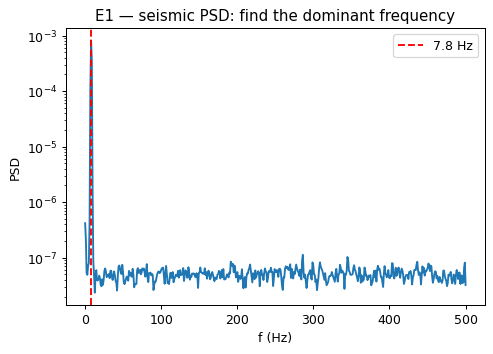

Var(ground)=1.25e-03, corr(signal,noise)=-0.014 (~0 -> justifies subtracting variances)


In [97]:
seis = np.loadtxt(f'{DATA}/seismic_test_dataset.txt', skiprows=1, delimiter=',')
t_seis, V_signal, V_noise = seis[:, 0], seis[:, 1], seis[:, 2]
dt_seis = t_seis[1] - t_seis[0]

f_seis, Pxx_seis = signal.welch(V_signal, fs=1/dt_seis, nperseg=1024)
dominant_freq = f_seis[np.argmax(Pxx_seis)]
print(f"dominant frequency: {dominant_freq:.2f} Hz")

plt.figure(figsize=(6, 4))
plt.semilogy(f_seis, Pxx_seis)
plt.axvline(dominant_freq, color='r', ls='--', label=f'{dominant_freq:.1f} Hz')
plt.xlabel('f (Hz)'); plt.ylabel('PSD'); plt.legend()
plt.title('E1 — seismic PSD: find the dominant frequency')
plt.show()

# variance decomposition (independent noise): Var(signal) = Var(ground) + Var(noise)
var_ground = np.var(V_signal) - np.var(V_noise)
corr_sn = np.corrcoef(V_signal, V_noise)[0, 1]
print(f"Var(ground)={var_ground:.2e}, corr(signal,noise)={corr_sn:.3f} (~0 -> justifies subtracting variances)")


tau_hat=37.16 s, P(T<=30s)=0.554


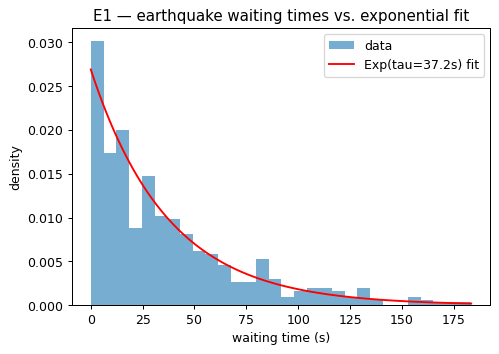

In [98]:
waiting = np.loadtxt(f'{DATA}/earthquake_waiting_times.txt', skiprows=1)
tau_hat = np.mean(waiting)                     # MLE of the exponential mean
P_le_30 = 1 - np.exp(-30 / tau_hat)
print(f"tau_hat={tau_hat:.2f} s, P(T<=30s)={P_le_30:.3f}")

t_axis = np.linspace(0, waiting.max(), 200)
plt.figure(figsize=(6, 4))
plt.hist(waiting, bins=30, density=True, alpha=0.6, label='data')
plt.plot(t_axis, expon.pdf(t_axis, scale=tau_hat), 'r-', label=f'Exp(tau={tau_hat:.1f}s) fit')
plt.xlabel('waiting time (s)'); plt.ylabel('density'); plt.legend()
plt.title('E1 — earthquake waiting times vs. exponential fit')
plt.show()


## E2. Bonus02 — Sensor Accuracy Model, Error Propagation, Bayes

Accuracy saturates exponentially with duration $x$: $y(x)=1-ae^{bx}$ ($b<0$). Linearize: $\ln(1-y)=\ln a+bx$.
Binomial SE: $\sigma_y=\sqrt{p(1-p)/N}$. Error propagation: $\sigma_y=|dy/dx|\sigma_x$.
Bayes: $P(K\mid M)=\dfrac{pP(K)}{pP(K)+(1-p)(1-P(K))}$; 2 independent confirmations: $p\to p^2$.


In [99]:
data = np.loadtxt(f'{DATA}/luftsensor_studie.txt', skiprows=1, delimiter=',')
duration = data[:,0]
sensor = data[:,1]
referenz = data[:,2]

unique_durations = np.unique(duration)
y_vals = []

for d in unique_durations:
    mask = (duration == d)
    total = np.sum(mask)
    correct = np.sum(sensor[mask] == referenz[mask])
    y_vals.append(correct / total)

b_fit, ln_a = np.polyfit(unique_durations, np.log(1 - np.array(y_vals)), 1)
a_fit = np.exp(ln_a)

print(f"a = {a_fit:.5f}")
print(f"b = {b_fit:.5f} 1/min")

a = 0.58379
b = -0.44769 1/min


In [100]:
def accuracy_func(t):
    return 1 - a_fit * np.exp(b_fit * t)

print(f"Accuracy at 3 min = {accuracy_func(3) * 100:.5f}%")

def get_time_for_acc(acc):
    return (np.log((1 - acc) / a_fit)) / b_fit

print(f"Time needed for 85% acc = {get_time_for_acc(0.85):.5f} min")

Accuracy at 3 min = 84.76038%
Time needed for 85% acc = 3.03540 min


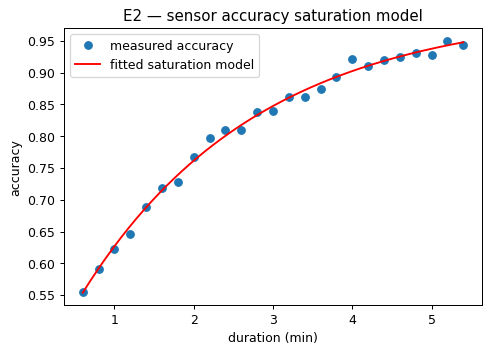

accuracy(3min)=0.848 +- 0.016 (95% CI), duration needed for 85%: 3.04 min
sigma_y from sigma_x=0.2min: 0.0136
P(K|M)=0.650, P(K|2 independent confirmations)=0.912


In [101]:
x_dense = np.linspace(unique_durations.min(), unique_durations.max(), 200)
plt.figure(figsize=(6, 4))
plt.plot(unique_durations, y_vals, 'o', label='measured accuracy')
plt.plot(x_dense, accuracy_func(x_dense), 'r-', label='fitted saturation model')
plt.xlabel('duration (min)'); plt.ylabel('accuracy'); plt.legend()
plt.title('E2 — sensor accuracy saturation model')
plt.show()

p3 = accuracy_func(3.0)
x_needed = np.log((1 - 0.85) / a_fit) / b_fit
N_samples = np.sum(duration == unique_durations[np.argmin(np.abs(unique_durations - 3.0))])
sigma_y = np.sqrt(p3 * (1-p3) / N_samples)
print(f"accuracy(3min)={p3:.3f} +- {2*sigma_y:.3f} (95% CI), duration needed for 85%: {x_needed:.2f} min")

sigma_x = 0.2
dy_dx = -a_fit * b_fit * np.exp(b_fit * 3.0)
print(f"sigma_y from sigma_x=0.2min: {abs(dy_dx)*sigma_x:.4f}")

P_K = 0.25
P_K_given_M  = (p3    * P_K) / (p3    * P_K + (1-p3)   * (1-P_K))
P_K_given_2M = (p3**2 * P_K) / (p3**2 * P_K + (1-p3)**2 * (1-P_K))
print(f"P(K|M)={P_K_given_M:.3f}, P(K|2 independent confirmations)={P_K_given_2M:.3f}")

## E3. Bonus03 — Model Comparison / Ensemble Voting

Standard pipeline: scale → split → fit several classifiers → compare validation accuracy → majority vote.


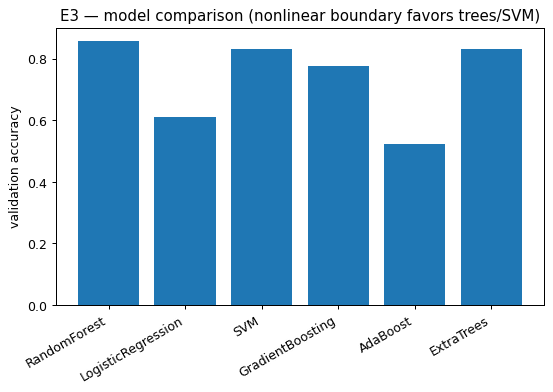

0 [1, 1, 1, 1, 1, 1] -> consensus: 1
1 [0, 0, 0, 0, 0, 0] -> consensus: 0
2 [1, 1, 1, 1, 0, 1] -> consensus: 1
3 [0, 0, 0, 1, 0, 0] -> consensus: 0
4 [1, 1, 1, 1, 0, 1] -> consensus: 1
5 [0, 0, 0, 0, 0, 0] -> consensus: 0


In [102]:
from sklearn.svm import SVC
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               AdaBoostClassifier, ExtraTreesClassifier)

train_e = pd.read_csv(f'{DATA}/ensemble_train.csv')
Xe, ye = train_e[['X1', 'X2', 'X3']], train_e['Target']
scaler_e = StandardScaler()
Xe_scaled = scaler_e.fit_transform(Xe)
Xe_train, Xe_val, ye_train, ye_val = train_test_split(Xe_scaled, ye, test_size=0.2, random_state=42)

models = {
    'RandomForest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'SVM':                SVC(kernel='rbf', random_state=42),
    'GradientBoosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'AdaBoost':           AdaBoostClassifier(n_estimators=100, random_state=42),
    'ExtraTrees':         ExtraTreesClassifier(n_estimators=100, random_state=42),
}
accs = {}
for name, m in models.items():
    m.fit(Xe_train, ye_train)
    accs[name] = accuracy_score(ye_val, m.predict(Xe_val))

plt.figure(figsize=(7, 4))
plt.bar(accs.keys(), accs.values())
plt.ylabel('validation accuracy'); plt.xticks(rotation=30, ha='right')
plt.title('E3 — model comparison (nonlinear boundary favors trees/SVM)')
plt.show()

# predict on genuinely new, unlabeled data -- reuse the SAME fitted scaler
new_e = pd.read_csv(f'{DATA}/ensemble_new.csv')
Xe_new_scaled = scaler_e.transform(new_e[['X1', 'X2', 'X3']])
preds = {name: m.predict(Xe_new_scaled) for name, m in models.items()}

for i in range(len(Xe_new_scaled)):
    row_preds = [int(preds[name][i]) for name in models]
    consensus = max(set(row_preds), key=row_preds.count)          # majority vote
    print(i, row_preds, "-> consensus:", consensus)


**Notes**
- Always reuse the same fitted `scaler` (`.transform`, never `.fit_transform()` again) on new/validation data.
- Low accuracy of `LogisticRegression`/`AdaBoost` vs. high accuracy of `RandomForest`/`SVM`/`ExtraTrees` is a strong hint the true decision boundary is nonlinear.
